In [ ]:
# Option 1: Clear all variables (doesn't restart kernel, but clears memory)
# %reset -f

# Option 2: Force kernel restart by exiting (run this to restart)
# import os
# os._exit(0)

# Option 3: Use IPython's built-in restart (if available)
# get_ipython().kernel.restart()

In order to run the bellow cells, download Amazon datasets for electronics from https://amazon-reviews-2023.github.io/main.html and place them in the /data folder.

In [2]:
import json
import pandas as pd


In [76]:
import matplotlib as plt

ModuleNotFoundError: No module named 'matplotlib'

In [24]:
with open('../../Data/meta_Movies_and_TV.jsonl/meta_Movies_and_TV.jsonl', 'r') as f:
    first_line_meta = json.loads(f.readline())


In [25]:
first_line_meta

{'main_category': 'Prime Video',
 'title': 'Glee',
 'subtitle': 'UnentitledUnentitled',
 'average_rating': 4.7,
 'rating_number': 2004,
 'features': ['IMDb 6.8', '2013', '22 episodes', 'X-Ray', 'TV-14'],
 'description': ['Entering its fourth season, this year the members of New Directions compete amongst themselves to be the "new Rachel" and hold auditions to find new students. Meanwhile, the graduating class leaves the comforts of McKinley where Rachel struggles to please her demanding NYADA teacher (Kate Hudson) and Kurt second-guesses his decision to stay in Lima. Four newcomers also join the musical comedy.'],
 'price': 22.39,
 'images': [{'360w': 'https://images-na.ssl-images-amazon.com/images/S/pv-target-images/8251ee0b9f888d262cd817a5f1aee0b29ffed56a4535af898b827292f881e169._RI_SX360_FMwebp_.jpg',
   '480w': 'https://images-na.ssl-images-amazon.com/images/S/pv-target-images/8251ee0b9f888d262cd817a5f1aee0b29ffed56a4535af898b827292f881e169._RI_SX480_FMwebp_.jpg',
   '720w': 'https

In [51]:
result=first_line_meta['subtitles'][0]

KeyError: 'subtitles'

In [43]:
result

'UnentitledUnentitled'

In [14]:
with open('C:/Users/61415/OneDrive/Documents/GitHub/AI-Engineering-Bootcamp/Data/Movies_and_TV.jsonl/Movies_and_TV.jsonl', 'r') as f:
    first_line_review = json.loads(f.readline())


In [44]:
first_line_review

{'rating': 5.0,
 'title': 'Five Stars',
 'text': "Amazon, please buy the show! I'm hooked!",
 'images': [],
 'asin': 'B013488XFS',
 'parent_asin': 'B013488XFS',
 'user_id': 'AGGZ357AO26RQZVRLGU4D4N52DZQ',
 'timestamp': 1440385637000,
 'helpful_vote': 0,
 'verified_purchase': True}

In [16]:
def filter_data(data: dict) -> dict:
    filter = False
    if int(data['details']['Date First Available'][-4:]) < 2022:
        filter = True

    return filter

Function to fIlter Movies with IMDB rating less that 2022

In [21]:
def filter_data(data: dict) -> dict:
    filter = False
    if int(data['features'][1]) < 2022:
        filter = True

    return filter

Split movies in 2 files based on IMDB rating year

In [ ]:
with open('../../Data/meta_Movies_and_TV.jsonl/meta_Movies_and_TV.jsonl', 'r') as fp:
    with open("../../Data/meta_Movies_and_TV.jsonl/meta_Movies_2022_2023.jsonl", 'a', encoding='utf-8') as fp_out:
        with open("../../data/meta_Movies_2022_2023_no_date.jsonl", 'a', encoding='utf-8') as fp_out_no_date:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    filter = filter_data(data)
                    if not filter:
                        json.dump(data, fp_out)
                        fp_out.write('\n')
                        fp_out.flush()
                except:
                    json.dump(data, fp_out_no_date)
                    fp_out_no_date.write('\n')
                    fp_out_no_date.flush()
                i += 1
                if i % 10000 == 0:
                    print(f"Processed {i} lines")

Category split function

In [72]:
def filter_data_subtitle(data: dict) -> dict:
    filter = False
    if (data['details']['Subtitles'][0])=="English [CC]":
        filter = True

#"English [CC]"

    return filter

In [71]:
with open('../../Data/meta_Movies_and_TV.jsonl/meta_Movies_2022_2023_no_date.jsonl', 'r') as fp:
        data = json.loads(fp.readline())
        details = (data['details']['Subtitles'][0])
        print(details)
        if (data['details']['Subtitles'][0])=="English [CC]":
                print(data['details']['Subtitles'][0])

English [CC]
English [CC]


In [68]:
type(details)

str

Split IMDB rating movies < 2022 into category vs no-category

In [ ]:
with open('../../Data/meta_Movies_and_TV.jsonl/meta_Movies_2022_2023_no_date.jsonl', 'r') as fp:
    with open("../../Data/meta_Movies_and_TV.jsonl/meta_Movies_2022_2023_English_CC.jsonl", 'a', encoding='utf-8') as fp_subtitle_out:
        with open("../../Data/meta_Movies_and_TV.jsonl/meta_Movies_2022_2023_no_Engllsh_CC.jsonl", 'a', encoding='utf-8') as fp_out_no_subtitle:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    filter = filter_data_subtitle(data)
                    if filter:
                        #print(line)
                        json.dump(data, fp_subtitle_out)
                        fp_subtitle_out.write('\n')
                        fp_subtitle_out.flush()
                except:
                    json.dump(data, fp_out_no_subtitle)
                    fp_out_no_subtitle.write('\n')
                    fp_out_no_subtitle.flush()
                i += 1
                if i % 10000 == 0:
                    print(f"Processed {i} lines")

load to pandas

In [5]:
df_subtitiles = pd.read_json('../../Data/meta_Movies_and_TV.jsonl/meta_Movies_2022_2023_English_CC.jsonl', lines=True)

In [6]:
df_subtitiles["description"].head()

0    [With her book tour in two weeks and his expan...
1    [The Empress Hotel is home to a rarified clien...
2    [HD. A pair of recent college graduates and th...
3    [Unlocking the Mystery of Life is a compelling...
4    [A thirty-something wife and mother is bored o...
Name: description, dtype: object

analyse movies by Genre

<Axes: xlabel='categories'>

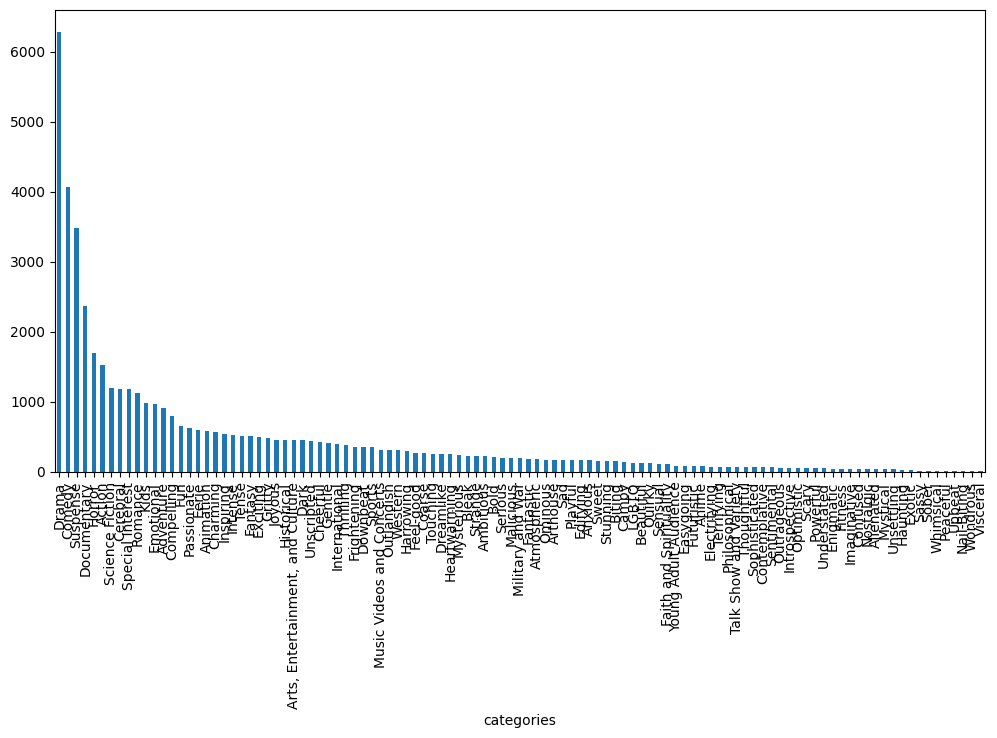

In [82]:
df_exploded = df_subtitiles.explode('categories')
category_counts = df_exploded['categories'].value_counts()
category_counts.plot(kind='bar', figsize=(12, 6))


In [85]:
category_counts.head()

categories
Drama          6282
Comedy         4067
Suspense       3476
Documentary    2369
Horror         1703
Name: count, dtype: int64

In [91]:
df_subtitiles['average_rating'].head()


0    3.0
1    3.4
2    4.2
3    4.6
4    3.4
Name: average_rating, dtype: float64

In [92]:
df_ratings_45 = df_subtitiles[df_subtitiles['average_rating'] >= 4.5]

In [93]:
df_ratings_45.head()

,main_category,title,subtitle,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
3,Prime Video,Unlocking the Mystery of Life,None,4.6,375.0,"[IMDb 6.1, 1 h 7 min, 2003, NR]",[Unlocking the Mystery of Life is a compelling...,9.99,[{'360w': 'https://m.media-amazon.com/images/G...,[],NaN,[Special Interest],"{'Audio languages': ['English'], 'Subtitles': ...",B004VYVMQM,NaN
5,Prime Video,Cry-Baby,None,4.7,11923.0,"[IMDb 6.5, 1 h 24 min, 1990, X-Ray, PG-13]",[Clean-cut 'squares' face off against hoodlum ...,16.79,[{'360w': 'https://images-na.ssl-images-amazon...,[],NaN,"[Comedy, Biting, Campy, Nostalgic]","{'Content advisory': ['Violence', 'smoking', '...",B009CG06FW,NaN
6,Prime Video,We're No Angels (1955),None,4.8,3036.0,"[IMDb 7.4, 1 h 45 min, 1955, X-Ray, 13+]","[In Christmas, three prisoners - Joseph, Alber...",12.99,[{'360w': 'https://images-na.ssl-images-amazon...,[],NaN,"[Comedy, Romance, Cheerful, Gentle]","{'Audio languages': ['English'], 'Subtitles': ...",B0020R57SQ,NaN
12,Prime Video,Shrimp on the Barbie,None,4.6,1000.0,"[IMDb 5.6, 1 h 26 min, 1990, 13+]",[Down on his luck and working in a Mexican res...,0.99,[{'360w': 'https://images-na.ssl-images-amazon...,[],NaN,[Comedy],"{'Content advisory': ['Nudity', 'violence', 'a...",B00MIIOYX6,NaN
16,Prime Video,Wadjda,None,4.6,557.0,"[IMDb 7.5, 1 h 37 min, 2012, X-Ray, PG]",[The story of a fun-loving 10-year old girl de...,12.99,[{'360w': 'https://m.media-amazon.com/images/G...,[],NaN,"[Comedy, Drama, Emotional, Gentle]","{'Audio languages': ['English'], 'Subtitles': ...",B00HZSAZ28,NaN


<Axes: xlabel='categories'>

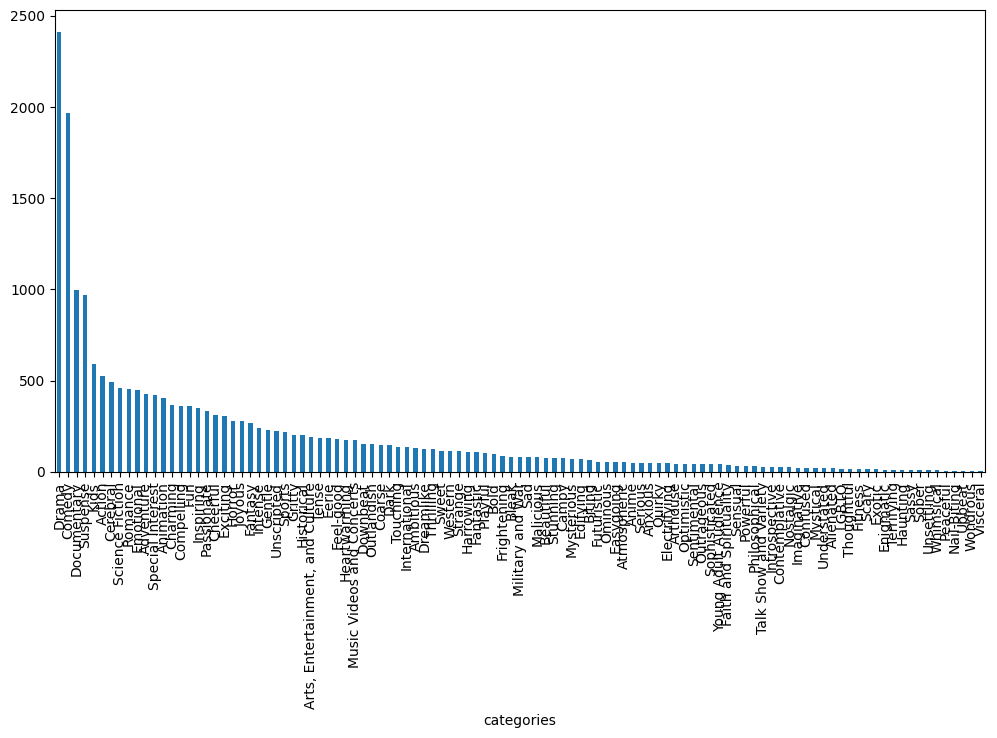

In [94]:
df_exploded = df_ratings_45.explode('categories')
category_counts = df_exploded['categories'].value_counts()
category_counts.plot(kind='bar', figsize=(12, 6))

In [96]:
len(df_ratings_45)


106813

In [97]:
df_sample_2000 = df_ratings_45.sample(n=2000, random_state=42)


<Axes: xlabel='categories'>

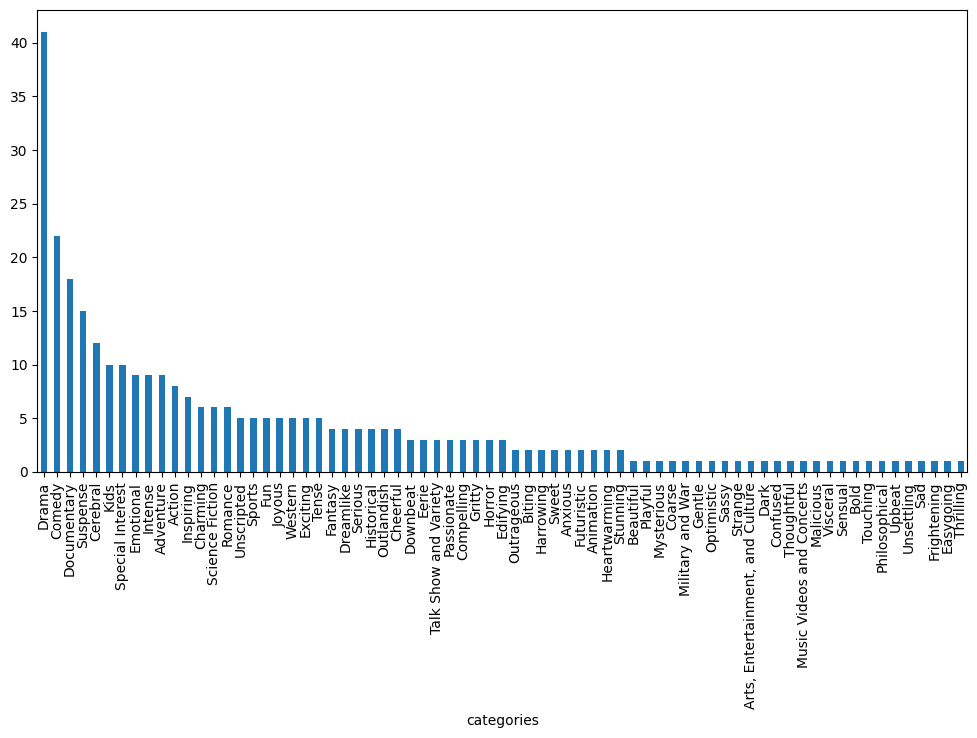

In [99]:
df_exploded = df_sample_2000.explode('categories')
category_counts = df_exploded['categories'].value_counts()
category_counts.plot(kind='bar', figsize=(12, 6))

In [ ]:
len(df_sample_2000) #2000
len(df_ratings_45) #106813



106813

Write ratings and sample files into a data folder

In [106]:
df_ratings_45.to_json('../../Data/ratings_45.jsonl', orient='records', lines=True)

In [107]:
df_sample_2000.to_json('../../Data/sample_2000.jsonl', orient='records', lines=True)

In [3]:
df_ratings_45 = pd.read_json('../../Data/ratings_45.jsonl',lines=True)
df_sample_2000 = pd.read_json('../../Data/sample_2000.jsonl',lines=True)


In [4]:
df_sample_2000.head()

,main_category,title,subtitle,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Prime Video,None,None,4.7,65,None,None,NaN,[{'360w': 'https://m.media-amazon.com/images/G...,[],NaN,None,"{'Content advisory': ['Violence', 'alcohol use...",B01LYA41BY,NaN
1,Prime Video,None,None,4.6,97881,None,None,NaN,[{'360w': 'https://images-na.ssl-images-amazon...,[],NaN,None,"{'Content advisory': ['Violence', 'alcohol use...",B00ZHWD78I,NaN
2,Prime Video,None,None,4.9,18911,None,None,NaN,[{'360w': 'https://images-na.ssl-images-amazon...,[],NaN,None,"{'Content advisory': ['Violence', 'substance u...",B00U7Q0CXC,NaN
3,Prime Video,None,None,4.6,1346,None,None,NaN,[{'360w': 'https://images-na.ssl-images-amazon...,[],NaN,None,"{'Content advisory': ['Violence', 'alcohol use...",B01HUGA1AU,NaN
4,Prime Video,None,None,4.6,114,None,None,NaN,[{'360w': 'https://images-na.ssl-images-amazon...,[],NaN,None,"{'Content advisory': ['Violence', 'smoking', '...",B00TE84WCG,NaN


In [ ]:
with open('../../Data/Movies_and_TV.jsonl/Movies_and_TV.jsonl', 'r') as f:
    first_line_review = json.loads(f.readline())

first_line_review


In [ ]:
with open('../../Data/Movies_and_TV.jsonl/Movies_and_TV.jsonl', 'r') as fp:
    with open('../../Data/Movies_and_TV.jsonl/Movies_and_TV_ratings_45.jsonl', 'a') as fp_out:
        id_list = set(df_ratings_45['parent_asin'].values)
        i = 0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write('\n')
                fp_out.flush()
            i += 1
            if i % 100000 == 0:
                print(f"Processed {i} lines")

In [111]:
with open('../../Data/Movies_and_TV.jsonl/Movies_and_TV_ratings_45.jsonl', 'r') as fp:
    with open('../../Data/Movies_and_TV.jsonl/Movies_and_TV_ratings_sample_2000.jsonl', 'a') as fp_out:
        id_list = set(df_sample_2000['parent_asin'].values)
        i = 0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write('\n')
                fp_out.flush()
            i += 1
            if i % 100000 == 0:
                print(f"Processed {i} lines")

Processed 100000 lines
Processed 200000 lines
Processed 300000 lines
Processed 400000 lines
Processed 500000 lines
Processed 600000 lines
Processed 700000 lines
Processed 800000 lines
Processed 900000 lines
Processed 1000000 lines
Processed 1100000 lines
Processed 1200000 lines
Processed 1300000 lines
Processed 1400000 lines
Processed 1500000 lines
Processed 1600000 lines
Processed 1700000 lines
Processed 1800000 lines
Processed 1900000 lines
Processed 2000000 lines
Processed 2100000 lines
Processed 2200000 lines
Processed 2300000 lines
Processed 2400000 lines
Processed 2500000 lines
Processed 2600000 lines
Processed 2700000 lines
Processed 2800000 lines
Processed 2900000 lines
Processed 3000000 lines
Processed 3100000 lines
Processed 3200000 lines
Processed 3300000 lines
Processed 3400000 lines
Processed 3500000 lines
Processed 3600000 lines
Processed 3700000 lines
Processed 3800000 lines
Processed 3900000 lines
Processed 4000000 lines
Processed 4100000 lines
Processed 4200000 lines
P